<a href="https://colab.research.google.com/github/Sanjana-Kannoorkar/Decision-Tree-and-Random-Forest/blob/main/task5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import graphviz

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import accuracy_score

In [44]:
#Load the dataset
df = pd.read_csv('heart.csv')

#Printing basic information about the dataset
print("Dataset shape: ", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types and missing values: ")
print(df.info())
print("\nSummary statistics: ")
print(df.describe())
print("\nTarget value distribution: ")
print(df['target'].value_counts())

Dataset shape:  (1025, 14)

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Data types and missing values: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3  

In [45]:
#Separate features and target
X = df.drop('target', axis = 1)
y = df['target']

#Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print("\nTrain set shape: ", X_train.shape)
print("Test set shape: ", X_test.shape)


Train set shape:  (820, 13)
Test set shape:  (205, 13)


In [46]:
#Initialize and train a Decision Tree Classifier
dt_clf = DecisionTreeClassifier(random_state = 42)
dt_clf.fit(X_train, y_train)

#Make predictions
y_train_pred = dt_clf.predict(X_train)
y_test_pred = dt_clf.predict(X_test)

#Evaluate performance
train_accuracy = accuracy_score(y_train, y_train)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nDecision Tree Performance:")
print(f"Traning Accuaracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report (Test Set): ")
print(classification_report(y_test, y_test_pred))


Decision Tree Performance:
Traning Accuaracy: 1.0000
Test Accuracy: 0.9854

Classification Report (Test Set): 
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



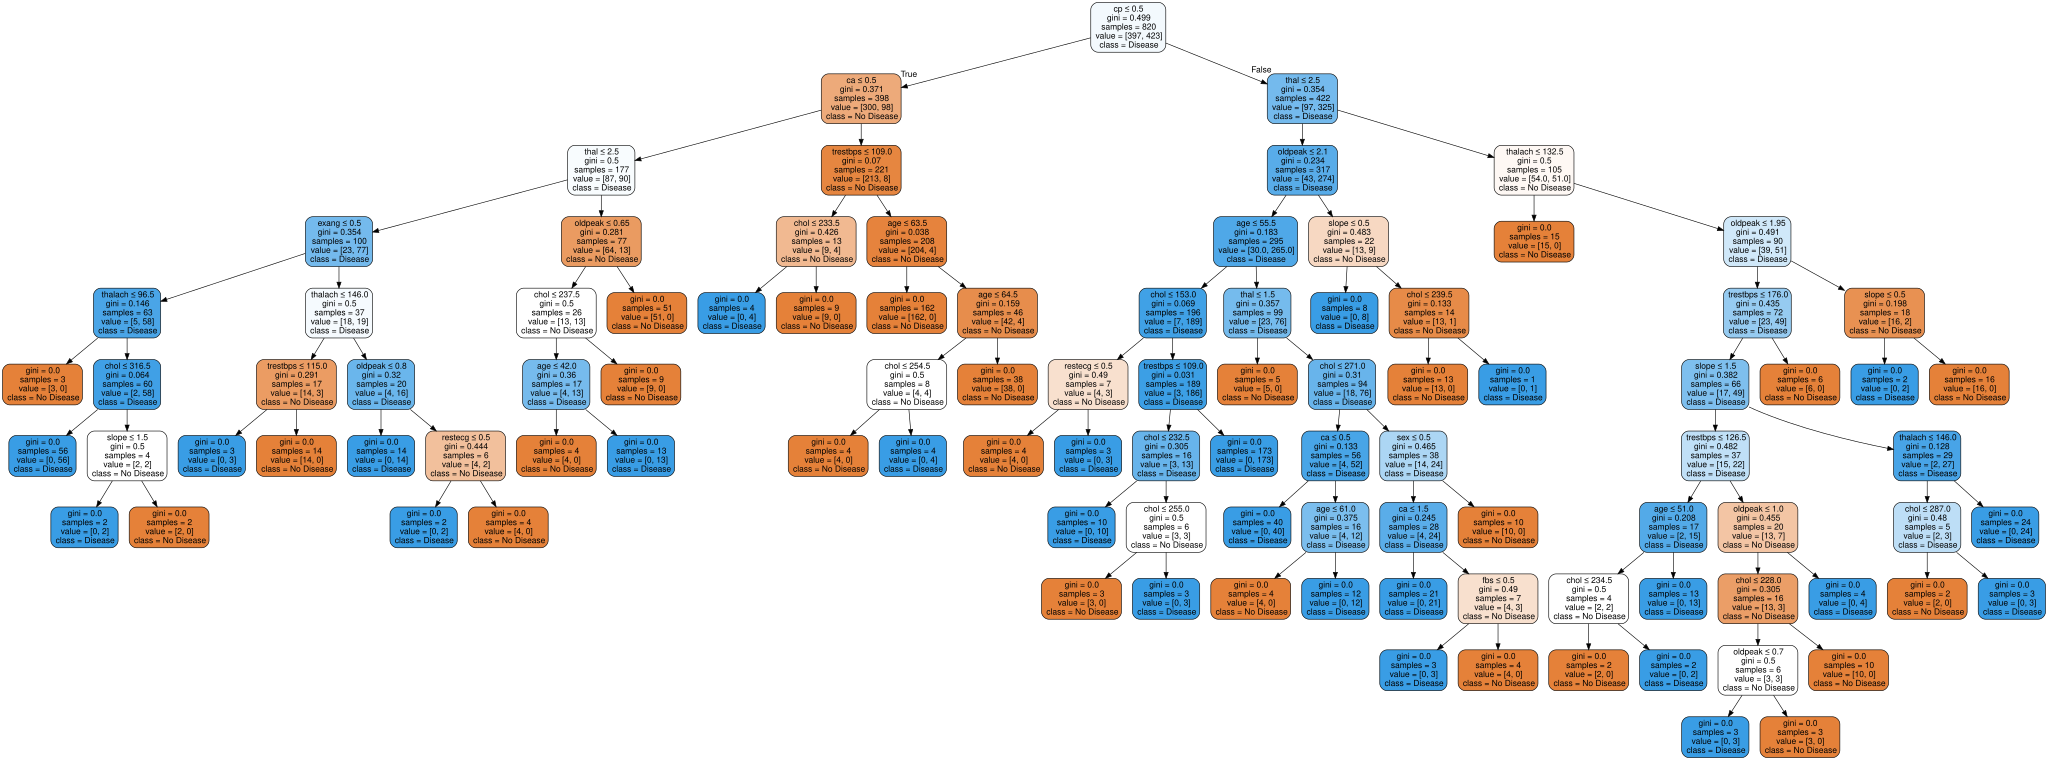

In [47]:
#Export the decision ress as DOT file
dot_data = export_graphviz(dt_clf, out_file = None, feature_names = X.columns, class_names = ['No Disease', 'Disease'], filled = True, rounded = True, special_characters = True)

#Create and render the graph
graph = graphviz.Source(dot_data)
graph
#graph.render('heart_disease_decision_tree')
#print("\nDecision tree Visualization saved as 'heart_disease_decision_tree.pdf")

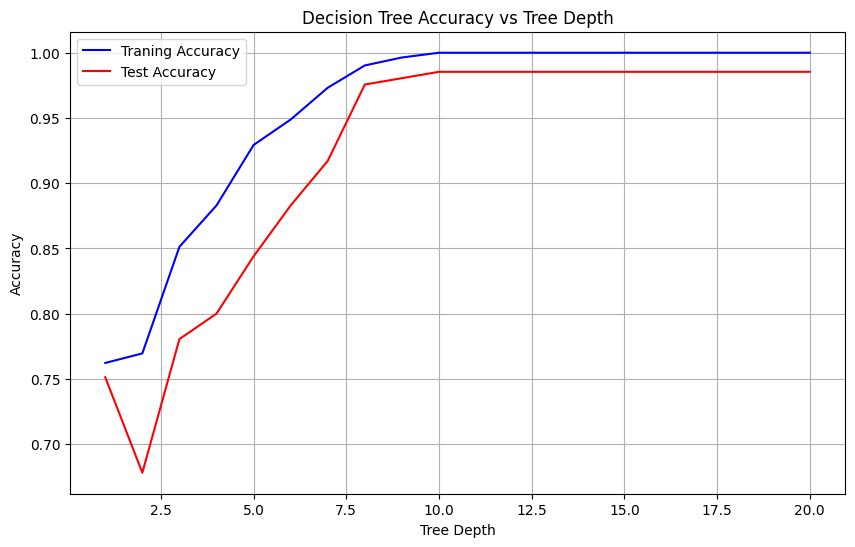

In [17]:
#Test different tree depths
max_depths = range(1, 21)
train_acc = []
test_acc = []

for depth in max_depths:
  dt_clf = DecisionTreeClassifier(max_depth = depth, random_state = 42)
  dt_clf.fit(X_train, y_train)
  train_acc.append(accuracy_score(y_train, dt_clf.predict(X_train)))
  test_acc.append(accuracy_score(y_test, dt_clf.predict(X_test)))

#Plotting
plt.figure(figsize = (10, 6))
plt.plot(max_depths, train_acc, 'b-', label = 'Traning Accuracy')
plt.plot(max_depths, test_acc, 'r-', label = 'Test Accuracy')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs Tree Depth')
plt.legend()
plt.grid()
plt.show()

In [19]:
#Find optimal depth
optimal_depth = max_depths[test_acc.index(max(test_acc))]
print(f"\nOptimal Tree Depth: {optimal_depth}")
print(f"Best Test accuracy: {max(test_acc):.4f} at depth {optimal_depth}")

#Train with optimal depth
optimal_dt  =DecisionTreeClassifier(max_depth = optimal_depth, random_state = 42)
optimal_dt.fit(X_train, y_train)

#Evaluate
y_pred  = optimal_dt.predict(X_test)
print("\nOptimized Decision Tree Performance: ")
print(f"Test Accuracyy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Optimal Tree Depth: 10
Best Test accuracy: 0.9854 at depth 10

Optimized Decision Tree Performance: 
Test Accuracyy: 0.9854

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205




Feature Importances: 
     Feature  Importances
2         cp     0.274524
12      thal     0.147141
11        ca     0.118901
4       chol     0.096328
9    oldpeak     0.094503
0        age     0.055125
7    thalach     0.053874
3   trestbps     0.047069
10     slope     0.043984
1        sex     0.026434
8      exang     0.018866
6    restecg     0.014881
5        fbs     0.008371


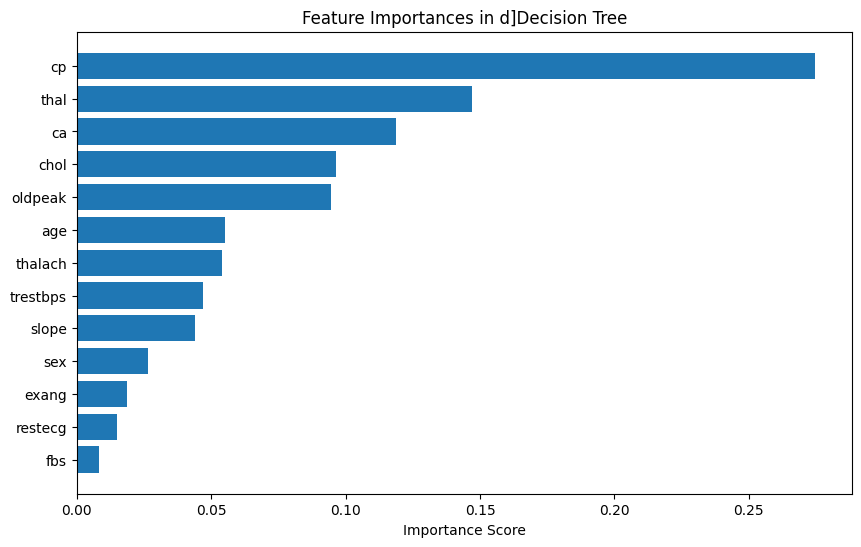

In [22]:
#Feature Importance analysis
importances = optimal_dt.feature_importances_
features  = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importances': importances})
importance_df = importance_df.sort_values('Importances', ascending = False)

print("\nFeature Importances: ")
print(importance_df)

plt.figure(figsize = (10, 6))
plt.barh(importance_df ['Feature'], importance_df['Importances'])
plt.xlabel('Importance Score')
plt.title('Feature Importances in d]Decision Tree')
plt.gca().invert_yaxis()
plt.show()

In [43]:
#Initialize and train random Forest
rf_clf = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_clf.fit(X_train, y_train)

y_train_pred = rf_clf.predict(X_train)
y_test_pred = rf_clf.predict(X_test)

print("\nRandoem Forest Performance: ")
print(f"Traning Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print("\nClassification Report (Test Set): ")
print(classification_report(y_test, y_test_pred))


Randoem Forest Performance: 
Traning Accuracy: 1.0000
Test Accuracy: 0.9854

Classification Report (Test Set): 
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205




Random Forest Importances: 
     Feature  Importance
2         cp    0.135072
11        ca    0.127327
7    thalach    0.122169
9    oldpeak    0.121905
12      thal    0.110518
0        age    0.077908
4       chol    0.074822
3   trestbps    0.071171
8      exang    0.057594
10     slope    0.045782
1        sex    0.028731
6    restecg    0.018557
5        fbs    0.008444


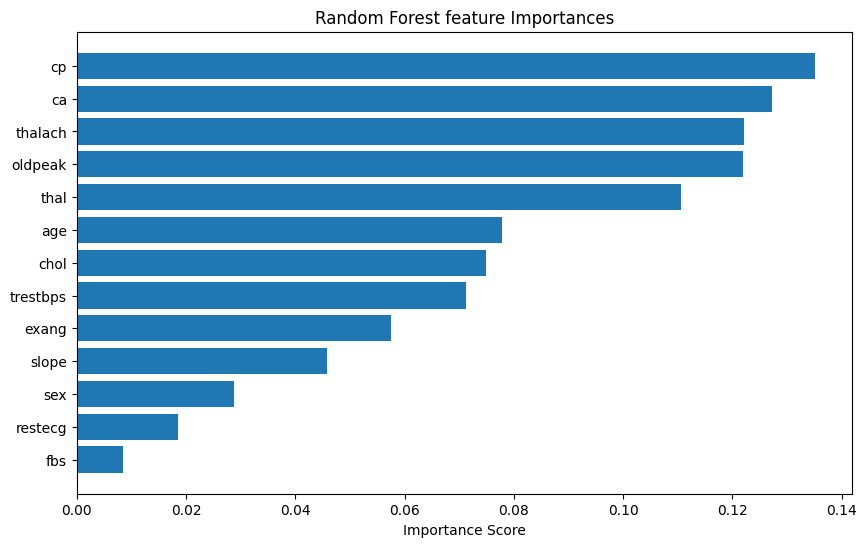

In [39]:
#Random Forest Feature Importance
rf_importances = rf_clf.feature_importances_
rf_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf_importances})
rf_importance_df = rf_importance_df.sort_values('Importance', ascending  = False)

print("\nRandom Forest Importances: ")
print(rf_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(rf_importance_df['Feature'], rf_importance_df['Importance'])
plt.xlabel('Importance Score')
plt.title('Random Forest feature Importances')
plt.gca().invert_yaxis()
plt.show()

In [48]:
#Cross Validation for Decision Tree
dt_cv_scores = cross_val_score(dt_clf, X, y, cv=5)
print(f"\nCross-Validation Scores: {dt_cv_scores}")
print(f"Mean CV Accuracy: {dt_cv_scores.mean():.4f}")


# Cross Validation for Random Forest
rf_cv_scores = cross_val_score(rf_clf, X, y, cv=5)
print(f"\nCross-Validation Scores: {rf_cv_scores}")
print(f"Mean CV Accuracy: {rf_cv_scores.mean():.4f}")


Cross-Validation Scores: [1. 1. 1. 1. 1.]
Mean CV Accuracy: 1.0000

Cross-Validation Scores: [1.         1.         1.         1.         0.98536585]
Mean CV Accuracy: 0.9971
